<a href="https://colab.research.google.com/github/sakshi-26769/capstone-project/blob/main/capstone_final_market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing, Understanding, and Inspecting Data:
1. Perform preliminary data inspection and report the findings as the structure of the data, missing values, duplicates, etc.
2. Based on the findings from the previous questions, identify duplicates and remove them





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_excel("/content/data.xlsx")
country = pd.read_excel("/content/Country-Code.xlsx")

In [ ]:
print("Data Shape:", data.shape)
print("Country Shape:", country.shape)

Data Shape: (9551, 19)
Country Shape: (15, 2)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9550 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Price range           9551 non-null   int64  
 15  Aggregate rating     

In [ ]:
data.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,1
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [ ]:
print(data.duplicated(subset="Restaurant ID").sum())

0


In [ ]:
data_cleaned = data.drop_duplicates(subset="Restaurant ID",keep = 'first')

In [ ]:
data_cleaned.duplicated(subset="Restaurant ID").sum()

np.int64(0)

In [ ]:
print("Original Shape:", data.shape)
print("Cleaned Shape:", data_cleaned.shape)

Original Shape: (9551, 19)
Cleaned Shape: (9551, 19)


Performing EDA:
3. Explore the geographical distribution of the restaurants and identify the cities with the maximum and minimum number of restaurants
4. Restaurant franchising is a thriving venture. So, it is very important to explore the franchise with most national presence
5. Find out the ratio between restaurants that allow table booking vs. those that do not allow table booking
6. Find out the percentage of restaurants providing online delivery
7. Calculate the difference in number of votes for the restaurants that deliver and the restaurants that do not deliver

**Geographical Distribution of Restaurants**

In [ ]:
city_distribution = data["City"].value_counts()
city_distribution.head()

,count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25


In [ ]:
max_city = city_distribution.idxmax()
max_count = city_distribution.max()

print("City with maximum restaurants:", max_city)
print("Number of restaurants:", max_count)

City with maximum restaurants: New Delhi
Number of restaurants: 5473


In [ ]:
min_city = city_distribution.idxmin()
min_count = city_distribution.min()

print("City with minimum restaurants:", min_city)
print("Number of restaurants:", min_count)

City with minimum restaurants: Bandung
Number of restaurants: 1


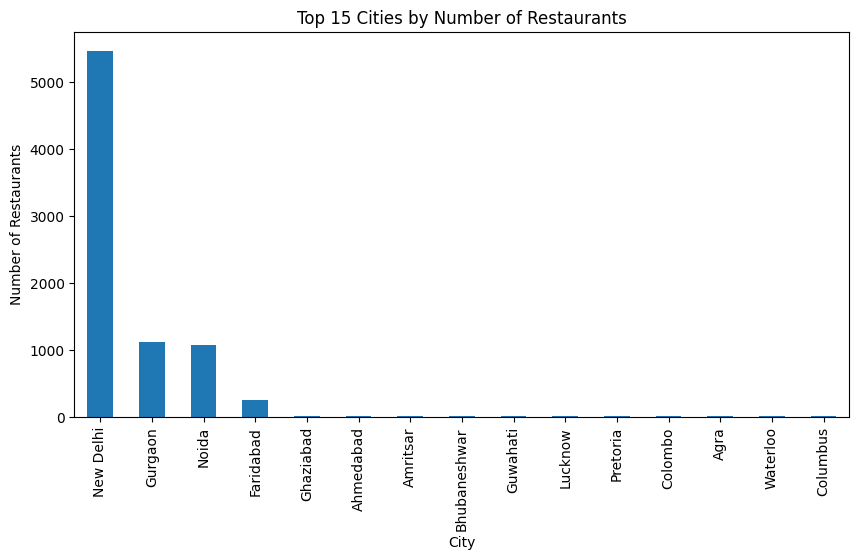

In [ ]:
city_distribution.head(15).plot(kind="bar", figsize=(10,5))
plt.title("Top 15 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.show()

**Franchise with Most National Presence**

In [ ]:
franchise = data.groupby("Restaurant Name")["City"].nunique()
franchise.sort_values(ascending=False).head()

,City
Restaurant Name,
Barbeque Nation,22
Pizza Hut,12
KFC,8
The Yellow Chilli,7
Domino's Pizza,7


**Ratio of Table Booking**

In [ ]:
table_booking_counts = data["Has Table booking"].value_counts()
table_booking_counts

,count
Has Table booking,
No,8393
Yes,1158


In [ ]:
yes_count = table_booking_counts.get("Yes", 0)
no_count = table_booking_counts.get("No", 0)

print("Restaurants allowing table booking:", yes_count)
print("Restaurants not allowing table booking:", no_count)

print("Ratio (Yes : No) =", yes_count, ":", no_count)

Restaurants allowing table booking: 1158
Restaurants not allowing table booking: 8393
Ratio (Yes : No) = 1158 : 8393


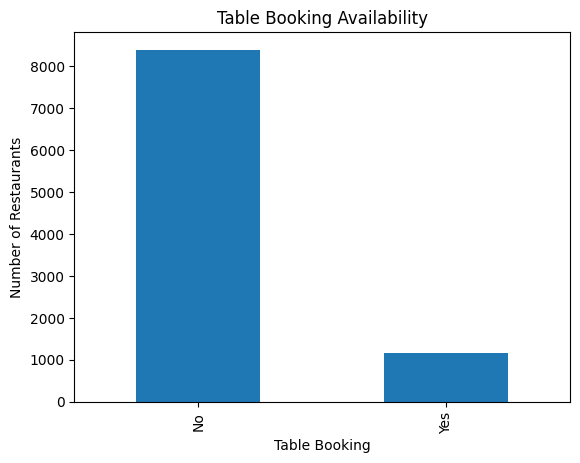

In [ ]:
import matplotlib.pyplot as plt

table_booking_counts.plot(kind="bar")
plt.title("Table Booking Availability")
plt.xlabel("Table Booking")
plt.ylabel("Number of Restaurants")
plt.show()


In [ ]:
total = yes_count + no_count

yes_percent = (yes_count / total) * 100
no_percent = (no_count / total) * 100

print(f"Allow Table Booking: {yes_percent:.2f}%")
print(f"Do Not Allow Table Booking: {no_percent:.2f}%")

Allow Table Booking: 12.12%
Do Not Allow Table Booking: 87.88%


**Percentage of Online Delivery**

In [ ]:
online_delivery = data["Has Online delivery"].value_counts()
percentage = (online_delivery["Yes"] / len(data)) * 100
print(round(percentage),2)

26 2


# OR

In [ ]:
online_delivery_counts = data["Has Online delivery"].value_counts()
online_delivery_counts

,count
Has Online delivery,
No,7100
Yes,2451


In [ ]:
yes_delivery = online_delivery_counts.get("Yes", 0)
no_delivery = online_delivery_counts.get("No", 0)

total_restaurants = yes_delivery + no_delivery

yes_percentage = (yes_delivery / total_restaurants) * 100
no_percentage = (no_delivery / total_restaurants) * 100

print(f"Restaurants providing online delivery: {yes_percentage:.2f}%")
print(f"Restaurants not providing online delivery: {no_percentage:.2f}%")

Restaurants providing online delivery: 25.66%
Restaurants not providing online delivery: 74.34%


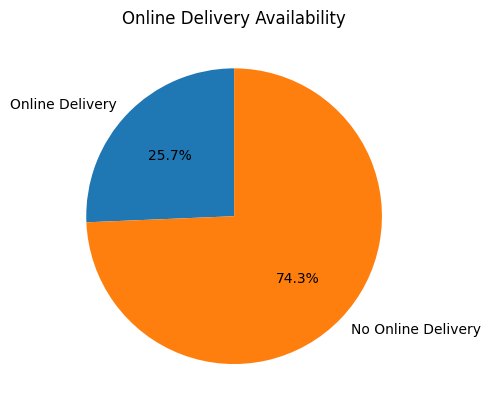

In [ ]:
labels = ['Online Delivery', 'No Online Delivery']
sizes = [25.66, 74.34]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Online Delivery Availability")
plt.show()

**Difference in Votes (Delivery vs No Delivery)**

In [ ]:
data.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Price range', 'Aggregate rating',
       'Rating color', 'Rating text', 'Votes'],
      dtype='object')

In [ ]:
votes_by_delivery = data.groupby("Has Online delivery")["Votes"].sum()
votes_by_delivery

,Votes
Has Online delivery,
No,980731
Yes,517914


In [ ]:
delivery_votes = votes_by_delivery.get("Yes", 0)
non_delivery_votes = votes_by_delivery.get("No", 0)

vote_difference = abs(delivery_votes - non_delivery_votes)

print("Total votes (Delivery):", delivery_votes)
print("Total votes (No Delivery):", non_delivery_votes)
print("Difference in votes:", vote_difference)

Total votes (Delivery): 517914
Total votes (No Delivery): 980731
Difference in votes: 462817


# OR

In [ ]:
votes = data.groupby("Has Online delivery")["Votes"].sum()
votes
votes["Yes"] - votes["No"]

np.int64(-462817)

Performing EDA:
1. What are the top 10 cuisines served across cities?
2. What is the maximum and minimum number of cuisines that a restaurant serves? Also, which is the most served cuisine across the restaurant for each city?
3. What is the distribution cost across the restaurants?
4. How ratings are distributed among the various factors?
5. Explain the factors in the data that may have an effect on ratings. For example, number of cuisines, cost, delivery option, etc.

In [ ]:
cuisine_data = data.dropna(subset=["Cuisines"])

In [ ]:
cuisine_series = cuisine_data["Cuisines"].str.split(", ")
cuisine_exploded = cuisine_series.explode()

In [ ]:
top_cuisines = cuisine_exploded.value_counts().head(10)
top_cuisines

,count
Cuisines,
North Indian,3960
Chinese,2735
Fast Food,1986
Mughlai,995
Italian,764
Bakery,745
Continental,736
Cafe,703
Desserts,653


**Cuisine Count Analysis**

In [ ]:
data['Cuisine_count'] = data['Cuisines'].apply(lambda x: len(str(x).split(',')))

In [ ]:
max_cuisines = data['Cuisine_count'].max()
min_cuisines = data['Cuisine_count'].min()
print(f"Maximum cuisines: {max_cuisines}, Minimum cuisines: {min_cuisines}")

Maximum cuisines: 8, Minimum cuisines: 1


In [ ]:
data_exploded = data.assign(Cuisine=data['Cuisines'].str.split(',')).explode('Cuisine')

In [ ]:
data_exploded['Cuisine'] = data_exploded['Cuisine'].astype(str).str.strip()
data_exploded = data_exploded[data_exploded['Cuisine'] != '']

In [ ]:
most_served_per_city = data_exploded.groupby('City')['Cuisine'] \
                                   .agg(lambda x: x.value_counts().idxmax() if not x.value_counts().empty else None)

print(most_served_per_city)

City
Abu Dhabi                Indian
Agra               North Indian
Ahmedabad           Continental
Albany                    Steak
Allahabad          North Indian
                       ...     
Weirton                  Burger
Wellington City            Cafe
Winchester Bay           Burger
Yorkton                   Asian
€¡stanbul              Desserts
Name: Cuisine, Length: 141, dtype: object


# OR

In [ ]:
# Count number of cuisines per restaurant
data['Cuisine_Count'] = data['Cuisines'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) else 0)

max_cuisines = data['Cuisine_Count'].max()
min_cuisines = data['Cuisine_Count'].min()
print(f"Maximum cuisines per restaurant: {max_cuisines}")
print(f"Minimum cuisines per restaurant: {min_cuisines}")

Maximum cuisines per restaurant: 8
Minimum cuisines per restaurant: 0


In [ ]:
data_exploded = data.assign(Cuisine=data['Cuisines'].str.split(',')).explode('Cuisine')

data_exploded['Cuisine'] = data_exploded['Cuisine'].astype(str).str.strip()
data_exploded = data_exploded[data_exploded['Cuisine'] != '']

most_served_per_city = data_exploded.groupby('City')['Cuisine'] \
    .agg(lambda x: x.value_counts().idxmax() if not x.value_counts().empty else None)

print(most_served_per_city)

City
Abu Dhabi                Indian
Agra               North Indian
Ahmedabad           Continental
Albany                    Steak
Allahabad          North Indian
                       ...     
Weirton                  Burger
Wellington City            Cafe
Winchester Bay           Burger
Yorkton                   Asian
€¡stanbul              Desserts
Name: Cuisine, Length: 141, dtype: object


**Cost Distribution**

**Overall rating distribution**

In [ ]:
data['Average Cost for two'].describe()

,Average Cost for two
count,9551.000000
mean,1199.210763
std,16121.183073
min,0.000000
25%,250.000000
50%,400.000000
75%,700.000000
max,800000.000000


**Rating distribution by Cost**

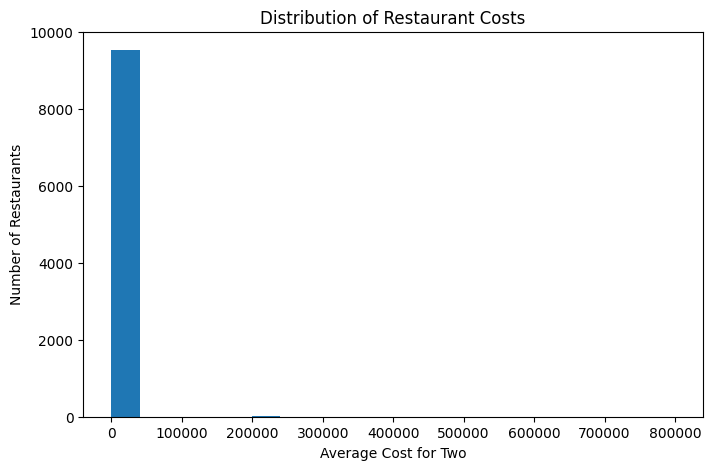

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(data['Average Cost for two'].dropna(), bins=20)
plt.xlabel('Average Cost for Two')
plt.ylabel('Number of Restaurants')
plt.title('Distribution of Restaurant Costs')
plt.show()

In [ ]:
bins = [0, 300, 600, 1000, 2000, 5000]
labels = ['Low', 'Medium', 'High', 'Very High', 'Luxury']

data['Cost_Category'] = pd.cut(
    data['Average Cost for two'],
    bins=bins,
    labels=labels
)

data['Cost_Category'].value_counts()

,count
Cost_Category,
Low,3494
Medium,3401
High,1463
Very High,917
Luxury,226


**Rating Distribution**

In [ ]:
rating_data = data[data['Aggregate rating'] > 0]

**Overall rating distribution**

In [ ]:
rating_data['Aggregate rating'].describe()

,Aggregate rating
count,7403.000000
mean,3.440024
std,0.552195
min,1.800000
25%,3.000000
50%,3.400000
75%,3.800000
max,4.900000


**Rating distribution by Cost**

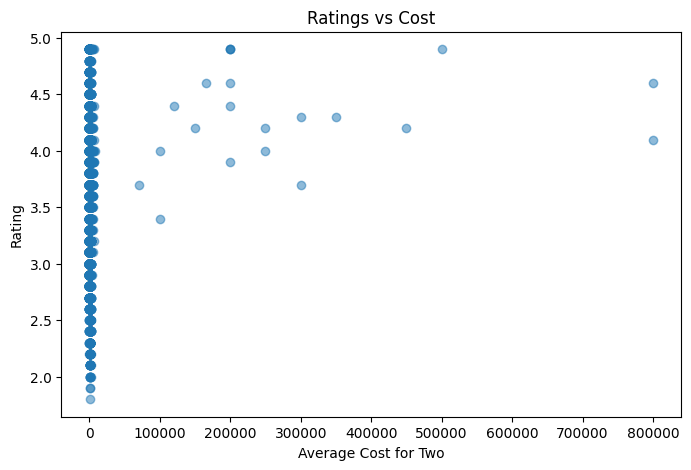

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(
    rating_data['Average Cost for two'],
    rating_data['Aggregate rating'],
    alpha=0.5
)
plt.xlabel('Average Cost for Two')
plt.ylabel('Rating')
plt.title('Ratings vs Cost')
plt.show()

**Rating distribution by Online Delivery**

In [ ]:
rating_data.groupby('Has Online delivery')['Aggregate rating'].mean()

,Aggregate rating
Has Online delivery,
No,3.467433
Yes,3.381274


**Rating distribution by Table Booking**

In [ ]:
rating_data.groupby('Has Table booking')['Aggregate rating'].mean()

,Aggregate rating
Has Table booking,
No,3.413970
Yes,3.587579


**Rating distribution by Cuisine Count**

In [ ]:
rating_data = rating_data.dropna(subset=['Cuisines'])
rating_data['Cuisine_Count'] = rating_data['Cuisines'].str.split(',').apply(len)

In [ ]:
rating_data['Cuisine_Count'] = (
    rating_data['Cuisines']
    .fillna('')
    .str.split(',')
    .apply(len)
)

In [ ]:
rating_data.groupby('Cuisine_Count')['Aggregate rating'].mean().head()

,Aggregate rating
Cuisine_Count,
1,3.404182
2,3.389003
3,3.488584
4,3.581149
5,3.598125


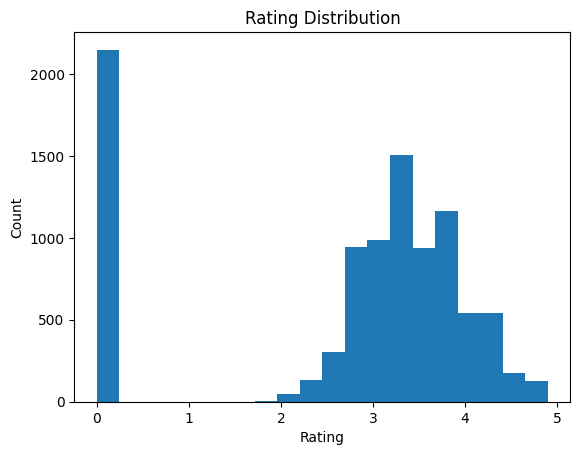

In [ ]:
plt.hist(data["Aggregate rating"].dropna(), bins=20)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.show()

**Factors Affecting Ratings**

In [ ]:
# Prepare clean rating data
rating_data = data[data['Aggregate rating'] > 0].copy()

In [ ]:
# Number of cuisines
rating_data = rating_data.dropna(subset=['Cuisines'])
rating_data['Cuisine_Count'] = rating_data['Cuisines'].str.split(',').apply(len)
rating_data.groupby('Cuisine_Count')['Aggregate rating'].mean().head()

,Aggregate rating
Cuisine_Count,
1,3.404182
2,3.389003
3,3.488584
4,3.581149
5,3.598125


In [ ]:
#Average cost for two
rating_data[['Average Cost for two', 'Aggregate rating']].corr()

,Average Cost for two,Aggregate rating
Average Cost for two,1.000000,0.076919
Aggregate rating,0.076919,1.000000


In [ ]:
# Online delivery option
rating_data.groupby('Has Online delivery')['Aggregate rating'].mean()

,Aggregate rating
Has Online delivery,
No,3.466720
Yes,3.381274


In [ ]:
# Table booking option
rating_data.groupby('Has Table booking')['Aggregate rating'].mean()

,Aggregate rating
Has Table booking,
No,3.413322
Yes,3.587579


In [ ]:
# Price range
rating_data.groupby('Price range')['Aggregate rating'].mean()

,Aggregate rating
Price range,
1,3.237692
2,3.377167
3,3.776715
4,3.890957


Dashboarding:
6. Visualize the variables using Tableau to help user explore the data and create a better understanding of the restaurants to identify the ‘’star’’ restaurant
7. Demonstrate  the variables associated with each other and factors to build a dashboard